# <font color=darkblue>**Universidad Nacional Autónoma de México**
# <font color=darkblue>**Facultad de Ciencias**
# <font color=orange>**Práctica 2 de Análisis Numérico**
## Alumnos:
# Galán Resendiz Andres Roberto
# Valentino Hernández Gael Emiliano

# Ejercicio 1
Escribe un programa que, mediante el método de eliminación de Gauss sin pivoteo, resuelva un sistema de ecuaciones de $n \times n$. Toma en cuenta las restricciones y condiciones que se deben cumplir para poder utilizar este método.

In [ ]:
import numpy as np
def gauss_sin_pivoteo(A, b):
    n = len(b)
    Ab = np.concatenate((A, b.reshape(n, 1)), axis=1).astype(float)
    for k in range(n):
        if Ab[k, k] == 0:
            raise ValueError(f"El pivote en la posición ({k},{k}) es cero. El método sin pivoteo no puede continuar.")
        for i in range(k + 1, n):
            factor = Ab[i, k] / Ab[k, k]
            Ab[i, k:] = Ab[i, k:] - factor * Ab[k, k:]
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        sumatoria = np.dot(Ab[i, i + 1 : n], x[i + 1 : n])
        x[i] = (Ab[i, n] - sumatoria) / Ab[i, i]
    return x

Prueba tu programa para resolver el sistema de ecuaciones:

$$\left(\begin{array}{cccc} 1 & -1 & 0 & 5\\ 3 & -2 & 1 & -1 \\ 1 & 1 & 9 & 4\\ 1 & -7 & 2 & 3 \end{array}\right) \left(\begin{array}{c}x_1\\x_2\\x_3\\x_4\end{array}\right) = \left(\begin{array}{c}18\\8\\47\\32\end{array}\right)$$

In [ ]:
A = np.array([[1, -1, 0, 5],
                  [3, -2, 1, -1],
                  [1,  1, 9, 4],
                  [1, -7, 2, 3]])

b = np.array([18, 8, 47, 32])
try:
    resultado = gauss_sin_pivoteo(A, b)
    print("Resultados:")
    for i, val in enumerate(resultado):
        print(f"x{i+1} = {val:.2f}")
except ValueError as e:
    print(f"Error: {e}")

Resultados:
x1 = 1.00
x2 = -2.00
x3 = 4.00
x4 = 3.00


## Ejercicio 2

Construye dos rutinas que resuelvan sistemas de ecuaciones lineales mediante los métodos de factorización LU y factorización de Cholesky. Toma en consideración las restricciones y consideraciones que se deben cumplir para cada método. Prueba tus rutinas con el sistema
$$
\left(\begin{array}{ccc} 1 & \frac{1}{2} & \frac{1}{3} \\ \frac{1}{2} & \frac{1}{3} & \frac{1}{4} \\ \frac{1}{3} & \frac{1}{4} & \frac{1}{5} \end{array}\right) \left(\begin{array}{c}x_1\\x_2\\x_3\end{array}\right) = \left(\begin{array}{c}18\\8\\47\end{array}\right)
$$

In [ ]:
import numpy as np
def resolver_sustituciones(L, U, b):
    n = len(b)
    y = np.zeros(n)
    for i in range(n):
        y[i] = (b[i] - np.dot(L[i, :i], y[:i])) / L[i, i]
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - np.dot(U[i, i+1:], x[i+1:])) / U[i, i]
    return x
def factorizacion_lu(A, b):
    n = len(A)
    L = np.eye(n)
    U = np.zeros((n, n))
    for i in range(n):
        for k in range(i, n): # Superior U
            U[i, k] = A[i, k] - np.dot(L[i, :i], U[:i, k])
        for k in range(i + 1, n): # Inferior L
            L[k, i] = (A[k, i] - np.dot(L[k, :i], U[:i, i])) / U[i, i]
    return resolver_sustituciones(L, U, b)
def factorizacion_cholesky(A, b):
    n = len(A)
    L = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1):
            suma = np.dot(L[i, :j], L[j, :j])
            if i == j:
                L[i, j] = np.sqrt(max(0, A[i, i] - suma))
            else:
                L[i, j] = (1.0 / L[j, j]) * (A[i, j] - suma)
    return resolver_sustituciones(L, L.T, b)

A = np.array([[1, 1/2, 1/3],
              [1/2, 1/3, 1/4],
              [1/3, 1/4, 1/5]])

b = np.array([18, 8, 47])

print("Ejemplo del problema:")
sol_lu = factorizacion_lu(A, b)
sol_cho = factorizacion_cholesky(A, b)

print(f"Resultado LU:       {sol_lu}")
print(f"Resultado Cholesky: {sol_cho}")

Ejemplo del problema:
Resultado LU:       [ 1284. -7572.  7560.]
Resultado Cholesky: [ 1284. -7572.  7560.]


## Ejercicio 3

Dado un conjunto de puntos $S = \lbrace \left( x_i,y_i\right):i=0,1,2...,n \rbrace$, con $x_i\neq x_j$ para todo $i\neq j$; escribe un programa que calcule los coeficientes $a_k$ del polinomio de grado $n$:

$$ P(x) = \overset{n}{\underset{k=0}{\sum}}a_k x^k$$

que pasa por cada punto de $S$. Y después escribe una rutina que pueda evaluar cualquier número real en la función $P(x)$ y que grafique a $P(x)$ en el intervalo $[x_0,x_n]$.

Prueba tu programa encontrando el polinomio de grado 2 que pasa por los puntos del conjunto $S=\lbrace (-1,144),(0,49),(1,4)\rbrace$, y el polinomio de grado 3 que pasa por los puntos de $S=\lbrace (-1,143),(0,49),(1,5),(2,17)\rbrace$

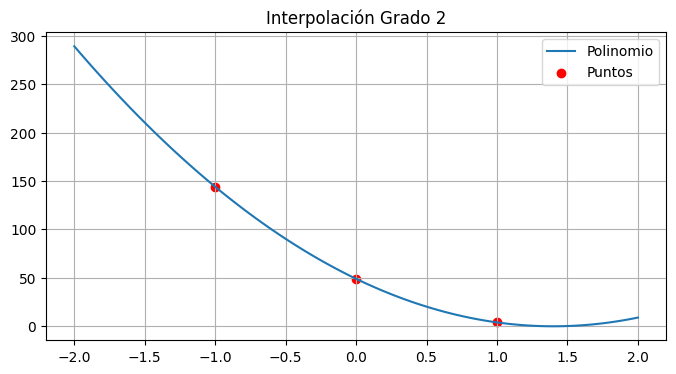

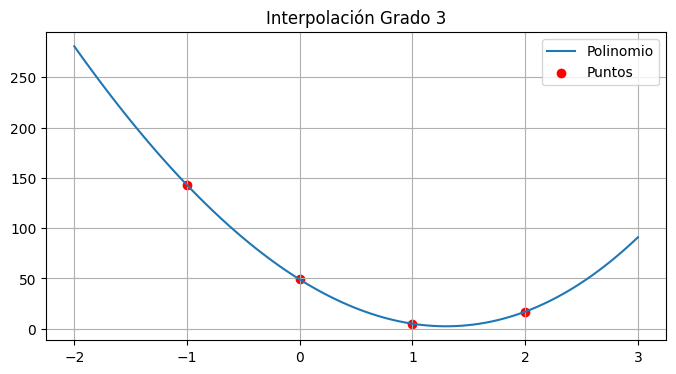

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
def calcular_polinomio(puntos):
    x_pts = np.array([p[0] for p in puntos])
    y_pts = np.array([p[1] for p in puntos])
    V = np.vander(x_pts, increasing=True)
    return np.linalg.solve(V, y_pts)
def evaluar_y_graficar(coefs, x_puntos, titulo):
    def P(x):
        return sum(a * (x**i) for i, a in enumerate(coefs))
    x_graf = np.linspace(min(x_puntos)-1, max(x_puntos)+1, 100)
    y_graf = [P(val) for val in x_graf]
    plt.figure(figsize=(8, 4))
    plt.plot(x_graf, y_graf, label="Polinomio")
    plt.scatter(x_puntos, [P(x) for x in x_puntos], color='red', label="Puntos")
    plt.title(titulo)
    plt.grid(True)
    plt.legend()
    plt.show()

# --- PRUEBAS ---
S1 = [(-1, 144), (0, 49), (1, 4)]
coefs1 = calcular_polinomio(S1)
evaluar_y_graficar(coefs1, [p[0] for p in S1], "Interpolación Grado 2")

S2 = [(-1, 143), (0, 49), (1, 5), (2, 17)]
coefs2 = calcular_polinomio(S2)
evaluar_y_graficar(coefs2, [p[0] for p in S2], "Interpolación Grado 3")

## Ejercicio 4

Escribe un programa que encuentre el polinomio interpolante de Newton para un conjunto de puntos $S = \{ (x_i, y_i) : i = 0, 1, \dots, n \}$. Además, este programa debe arrojar un valor $P(x)$ para cualquier valor $x$ introducido y graficar a $P(x)$ en el intervalo $[x_0, x_n]$.

Dados los siguientes valores de una función:

| $x$ | 0.0 | 1.0 | 2.0 | 3.0 | 4.0 | 5.0 |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| $f(x)$ | -7 | -4 | 5 | 26 | 65 | 128 |

Calcula, mediante el programa anterior, el polinomio que interpola los datos.

Coeficientes de Newton (b0, b1, ..., bn):
[-7.  3.  3.  1.  0.  0.]


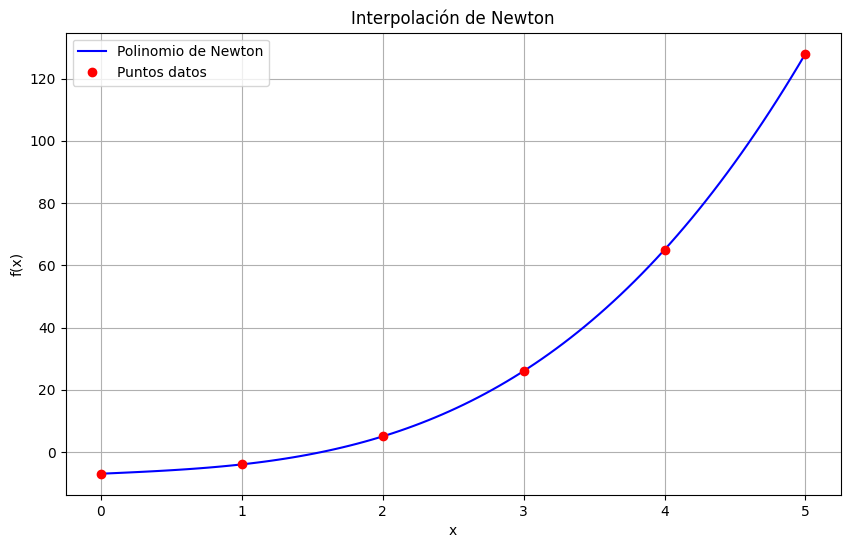


Evaluación en x = 2.5: P(2.5) = 13.625


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
def diferencias_divididas(x, y):
    n = len(y)
    coef = np.zeros([n, n])
    coef[:,0] = y
    for j in range(1, n):
        for i in range(n - j):
            coef[i,j] = (coef[i+1,j-1] - coef[i,j-1]) / (x[i+j] - x[i])
    return coef[0, :]
def evaluar_newton(coef, x_puntos, x_a_evaluar):
    n = len(coef) - 1
    p = coef[n]
    for k in range(1, n + 1):
        p = coef[n-k] + (x_a_evaluar - x_puntos[n-k]) * p
    return p

# 1- Datos xd
x_datos = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0])
y_datos = np.array([-7.0, -4.0, 5.0, 26.0, 65.0, 128.0])

# 2. coeficientes
coeficientes = diferencias_divididas(x_datos, y_datos)

print("Coeficientes de Newton (b0, b1, ..., bn):")
print(coeficientes)

# 3. Grafiquiña
x_graf = np.linspace(min(x_datos), max(x_datos), 100)
y_graf = [evaluar_newton(coeficientes, x_datos, val) for val in x_graf]
plt.figure(figsize=(10, 6))
plt.plot(x_graf, y_graf, 'b-', label='Polinomio de Newton')
plt.plot(x_datos, y_datos, 'ro', label='Puntos datos')
plt.title('Interpolación de Newton')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()
val_prueba = 2.5
resultado = evaluar_newton(coeficientes, x_datos, val_prueba)
print(f"\nEvaluación en x = {val_prueba}: P({val_prueba}) = {resultado}")

## Ejercicio 5

Escribe un programa que encuentre el polinomio interpolante de Lagrange para un conjunto de puntos $S = \{ (x_i, y_i) : i = 0, 1, \dots, n \}$. Además, este programa debe devolver un valor $P(x)$ para cualquier valor $x$ introducido y graficar a $P(x)$ en el intervalo $[x_0, x_n]$.

La presión de vapor del agua (en unidades de bar) como función de la temperatura $T$ (en $^\circ\text{C}$) es:

| $T$ | 0 | 10 | 20 | 30 | 40 | 60 | 80 | 100 |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| $P$ | 0.0061 | 0.0123 | 0.0234 | 0.0424 | 0.0738 | 0.1992 | 0.4736 | 1.0133 |

Calcula, mediante el programa anterior, el polinomio que interpola los datos. Por medio del polinomio encontrado, estima los valores de $P(5)$, $P(45)$ y $P(95)$.

Compara tus resultados con los valores conocidos de la presión: $P(5) = 0.008721$, $P(45) = 0.095848$ y $P(95) = 0.84528$. Calcula el error absoluto de los valores obtenidos a través del polinomio interpolante. ¿El polinomio interpolante describe bien la presión de vapor como función de la temperatura?

T (°C)     | P(T) Estima  | P(T) Real    | Error Absoluto 
-------------------------------------------------------
5          | 0.008691     | 0.008721     | 2.995793e-05   
45         | 0.095919     | 0.095848     | 7.059741e-05   
95         | 0.846173     | 0.845280     | 8.927926e-04   


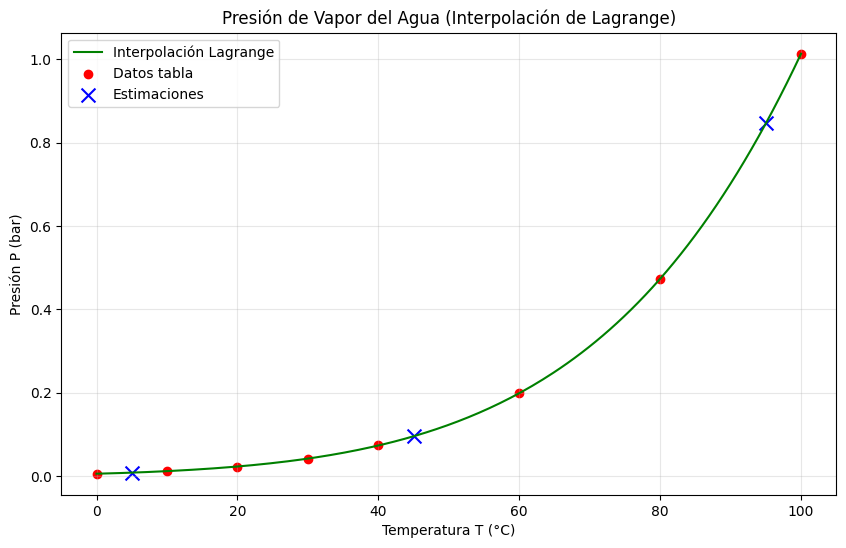

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
def interpolacion_lagrange(x_puntos, y_puntos, x_a_evaluar):
    n = len(x_puntos)
    resultado = 0
    for i in range(n):
        termino = y_puntos[i]
        for j in range(n):
            if i != j:
                termino = termino * (x_a_evaluar - x_puntos[j]) / (x_puntos[i] - x_puntos[j])
        resultado += termino
    return resultado
T_puntos = np.array([0, 10, 20, 30, 40, 60, 80, 100], dtype=float)
P_puntos = np.array([0.0061, 0.0123, 0.0234, 0.0424, 0.0738, 0.1992, 0.4736, 1.0133], dtype=float)
valores_reales = {5: 0.008721, 45: 0.095848, 95: 0.84528}
puntos_a_estimar = [5, 45, 95]

print(f"{'T (°C)':<10} | {'P(T) Estima':<12} | {'P(T) Real':<12} | {'Error Absoluto':<15}")
print("-" * 55)
estimaciones = []
for t in puntos_a_estimar:
    p_estima = interpolacion_lagrange(T_puntos, P_puntos, t)
    p_real = valores_reales[t]
    error = abs(p_estima - p_real)
    estimaciones.append(p_estima)
    print(f"{t:<10} | {p_estima:<12.6f} | {p_real:<12.6f} | {error:<15.6e}")
T_graf = np.linspace(min(T_puntos), max(T_puntos), 200)
P_graf = [interpolacion_lagrange(T_puntos, P_puntos, t) for t in T_graf]
plt.figure(figsize=(10, 6))
plt.plot(T_graf, P_graf, 'g-', label='Interpolación Lagrange')
plt.scatter(T_puntos, P_puntos, color='red', label='Datos tabla')
plt.scatter(puntos_a_estimar, estimaciones, color='blue', marker='x', s=100, label='Estimaciones')
plt.title('Presión de Vapor del Agua (Interpolación de Lagrange)')
plt.xlabel('Temperatura T (°C)')
plt.ylabel('Presión P (bar)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()